In [1]:
# import sys
# sys.path.insert(0, "/home/mlokken/software/pymsz")
import numpy as np
import pymsz
%load_ext autoreload
%autoreload 2

In [2]:
pymsz.__path__

['/cita/h/home-2/mlokken/software/pymsz/pymsz']

In [3]:
CENTER = np.array([500000, 500000, 500000], dtype=np.float32)
EXTRACTION_RADIUS = 20000.0  # kpc
ANGULAR_RESOLUTION = 5 # 30 # arcsec -- this sets the pixel size, not the smoothing. 0.5' is SO-like pixels
NPIXEL = 'auto'# 350*3
NCPU = 8
sim = pymsz.load_data(
            "/mnt/scratch-lustre/irosenberg/run/NEW_BH_JET_0kv3.bob/snaps/snap_097.hdf5", snapshot=True, center=CENTER, radius=EXTRACTION_RADIUS,
            cut_sfr=0.1, restrict_r=False
        )

reading files:  ['/mnt/scratch-lustre/irosenberg/run/NEW_BH_JET_0kv3.bob/snaps/snap_097.hdf5']
Reading /mnt/scratch-lustre/irosenberg/run/NEW_BH_JET_0kv3.bob/snaps/snap_097.hdf5 file with Header


In [4]:
sim.cosmology["z"]

0.9872814067431317

In [5]:
sim.prep_ss_TT()

In [6]:
np.mean(np.log10(sim.electron_number_density))

-4.9757886

In [7]:
np.mean(np.log10(sim.electron_number))

64.88672187837719

In [6]:
np.log10(sim.electron_temperature)

array([7.78047  , 7.752106 , 7.7635775, ..., 6.0499907, 5.887157 ,
       4.985814 ], dtype=float32)

In [30]:
pj = pymsz.TT_model(
            sim, label='tSZ', npixel=NPIXEL, axis='z', neighbours=128,
            redshift=sim.cosmology["z"], AR=ANGULAR_RESOLUTION, Ncpu=4,
            sph_kernel='cubic', Memreduce=True
        )

# do this for the electron number density instead
# pj = pymsz.TT_model(
#             sim, label='ne', npixel=NPIXEL, axis='z', neighbours=64,
#             redshift=sim.cosmology["z"], AR=ANGULAR_RESOLUTION, Ncpu=NCPU,
#             sph_kernel='cubic', Memreduce=True
#         )

Convert the neighbor count in pixel size:  32.84226701231143
Init smoothing, RAM=1.679 GB
After cKDTree , RAM=1.848 GB
Directly pass the cKDTree to tasks with Python version 3.10.2 (main, Jan 25 2022, 10:08:04) [GCC 8.5.0 20210514 (Red Hat 8.5.0-4)]


In [31]:
z = sim.cosmology["z"]

In [32]:
z

0.9872814067431317

In [33]:
pj.write_fits_image("/mnt/scratch-lustre/mlokken/agnvar_300/tSZ_NEW_BH_JET_0kv3_snap_097.fits", overwrite=True,
                                comments=f"Simulation redshift: {z:.2f}")

In [34]:
    
def load_ymap(file, print_header=False):
    from astropy.io import fits
    with fits.open(file, ignore_missing_simple=True) as file:
        hdr  = file[0].header
        if print_header:
            print(hdr)
        xcen = hdr['RCVAL1']
        ycen = hdr['RCVAL2']
        zcen = hdr['RCVAL3']
        pixsize  = hdr['PSIZE']
        ymap = file[0].data
    ysidelen_pix = ymap.shape[0]
    xsidelen_pix = ymap.shape[1]
    x_half_pix = xsidelen_pix // 2
    y_half_pix = ysidelen_pix // 2
    # Calculate the edges of the ymap
    xmin = xcen - (x_half_pix * pixsize)
    xmax = xcen + (x_half_pix * pixsize)
    ymin = ycen - (y_half_pix * pixsize)
    ymax = ycen + (y_half_pix * pixsize)

    # return all units in Mpc
    return ymap, xcen/1000, ycen/1000, zcen/1000, pixsize/1000, xmin/1000, xmax/1000, ymin/1000, ymax/1000

In [49]:
nemap, xcen, ycen, zcen, pixsize, xmin, xmax, ymin, ymax = load_ymap("/mnt/scratch-lustre/mlokken/agnvar_300/ne_NEW_BH_JET_0kv3_snap_097.fits")
ymap, xcen, ycen, zcen, pixsize, xmin, xmax, ymin, ymax = load_ymap("/mnt/scratch-lustre/mlokken/agnvar_300/tSZ_NEW_BH_JET_0kv3_snap_097.fits")

# get the T map simply by dividing, since we can't project temperature straightforwardly

M_sun = 1.9891e+33  # g
Kb = 1.38064852e-16
cs = 6.65245854533e-25
me = 9.10938291e-28
c = 29979245800.0
Kpc = 3.0856775809623245e+21
Mp = 1.672621777e-24
const = Kb * cs / me / c**2 / Kpc **2
Tmap = ymap / nemap / const # adjust for the extra terms in the y calculation

In [50]:
Tmap

array([[ 490646.43308593,  524863.26883853,  562028.53847776, ...,
        1991077.70808575, 2142162.95700134, 1908412.41276964],
       [ 531673.09071853,  558071.88063599,  586406.63187487, ...,
        2029515.25389142, 2022593.00903709, 1753905.37853161],
       [ 553651.45558274,  586112.98662771,  619811.05285209, ...,
        2063667.21904567, 2007773.02589139, 1600067.61068916],
       ...,
       [ 143345.52788635,  159094.50810281,  171796.14400271, ...,
         337344.35641217,  277664.34719788,  249572.40700529],
       [ 121222.81722878,  141272.30705593,  159046.29783197, ...,
         185322.12203391,  195571.42982152,  215559.94269044],
       [ 106913.40932752,  127731.83737196,  146876.20753835, ...,
         185104.12315892,  186892.24559555,  195275.79830755]])

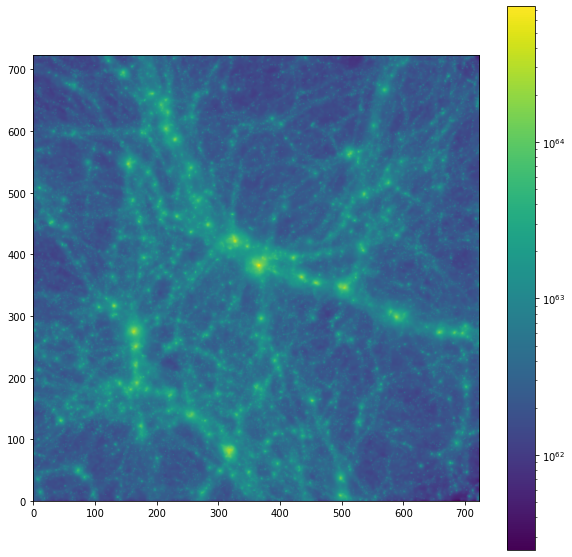

In [38]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
plt.figure(figsize=[10,10])
plt.imshow(nemap, origin='lower', cmap='viridis', norm=LogNorm())
plt.colorbar()

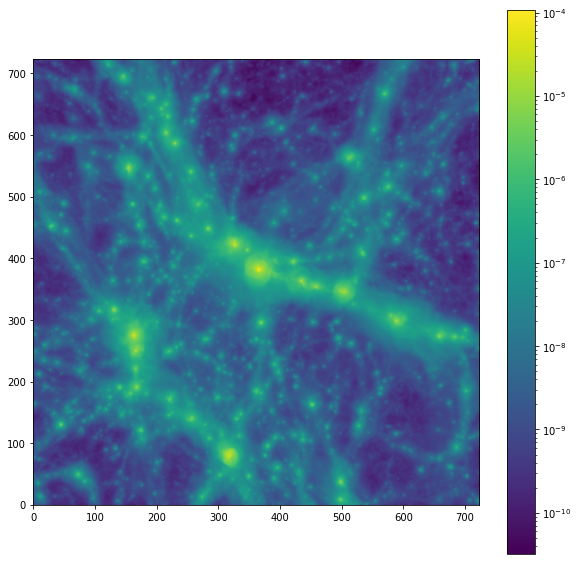

In [51]:
plt.figure(figsize=[10,10])
plt.imshow(ymap, origin='lower', cmap='viridis', norm=LogNorm())
plt.colorbar()

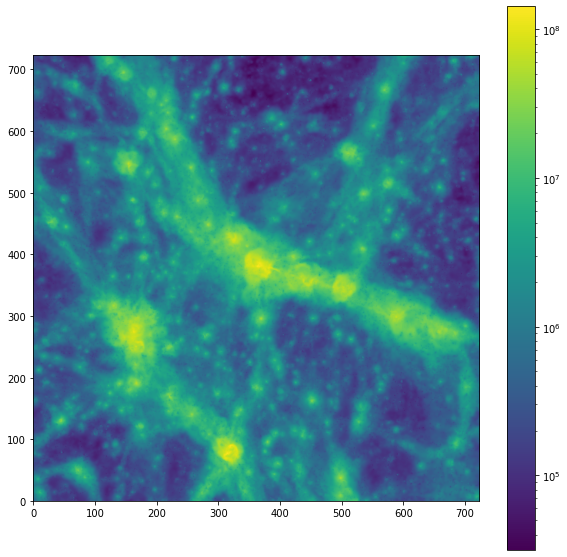

In [52]:
plt.figure(figsize=[10,10])
plt.imshow(Tmap, origin='lower', cmap='viridis', norm=LogNorm())
plt.colorbar()